<a href="https://colab.research.google.com/github/Tejaswini050302/Trader-Sentiment-Analysis-pt.ai/blob/main/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Primetrade.ai Internship Assignment (Data Science)**

---



# Trader Performance vs Market Sentiment

Objective:
Analyze the relationship between Bitcoin market sentiment (Fear/Greed) and trader performance on Hyperliquid.

In [120]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving historical_data.csv to historical_data.csv
Saving fear_greed_index.csv to fear_greed_index.csv


In [121]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

Dataset Overview

In [122]:
print("Fear and Greed Dataset")
print(sentiment.shape)
print()

print("Trade Dataset")
print(trades.shape)

Fear and Greed Dataset
(2644, 4)

Trade Dataset
(211224, 16)


In [123]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


Missing Values

In [124]:
print("Sentiment Missing Values")
print(sentiment.isnull().sum())
print()

print("Trades Missing Values")
print(trades.isnull().sum())

Sentiment Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


Duplicate Values

In [125]:
print("Sentiment Duplicates")
print(sentiment.duplicated().sum())
print()
print("Trades Duplicates")
print(trades.duplicated().sum())

Sentiment Duplicates
0

Trades Duplicates
0


Data Cleaning

In [126]:
sentiment["data"] = pd.to_datetime(sentiment["date"])

trades["Timestamp IST"] = pd.to_datetime(trades["Timestamp IST"], dayfirst= True)

In [127]:
trades["date"] = trades["Timestamp IST"].dt.date
trades["date"] = pd.to_datetime(trades["date"])

In [129]:
sentiment["date"] = pd.to_datetime(sentiment["date"])

trades["date"] = pd.to_datetime(trades["date"])

In [130]:
print(trades["date"].dtype)
print(sentiment["date"].dtype)

datetime64[ns]
datetime64[ns]


####Merging Datasets

Merged trader data with sentiment data using trading date.

In [131]:
df = pd.merge(trades,sentiment[["date","classification","value"]], on="date", how="left")

In [132]:
df.shape

(211224, 19)

In [133]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


---
## **Feature engineering**
---

After cleaning and merging the datasets, several derived features were created to analyze trader performance and behavior under different market sentiment conditions.

The following metrics were generated:

1. Win/Loss Indicator
2. Daily Profit & Loss (PnL)
3. Trade Count
4. Average Trade Size
5. Long/Short Bias
6. Trader Performance Summary

These features will be used in subsequent analysis and trader segmentation.

####**1. Win/Loss Indicator**

A win/loss indicator was created based on the Closed PnL of each trade.

- Winning Trade → Closed PnL > 0
- Losing Trade → Closed PnL ≤ 0

This feature is later used to calculate trader win rates and identify consistent performers.

In [74]:
df["win"] = (df["Closed PnL"] > 0).astype(int)

df[["Closed PnL", "win"]].head()

,Closed PnL,win
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


####**2. Daily Profit and Loss (PnL)**

Daily PnL measures the total profit or loss generated by each trader on a given day.

This metric helps evaluate how trader profitability changes under different market sentiment regimes such as Fear and Greed.

In [73]:
daily_pnl = (df.groupby(["date","Account"])["Closed PnL"].sum().reset_index())
daily_pnl.head()

,date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


####**3. Trade Count**

Trade count represents the number of trades executed.

This metric helps distinguish between:

- Frequent Traders
- Infrequent Traders


In [78]:
trade_count = (df.groupby("Account").size().reset_index(name="trade_count"))

trade_count.head()

,Account,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280
2,0x271b280974205ca63b716753467d5a371de622ab,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239


In [77]:
trade_count.describe()

,trade_count
count,32.000000
mean,6600.750000
std,8250.373724
min,332.000000
25%,1381.750000
50%,3699.000000
75%,8862.500000
max,40184.000000


####**4. Average Trade Size**

Average trade size measures the typical amount of capital deployed by a trader.

Larger trade sizes generally imply higher market exposure and potentially higher risk.

In [79]:
avg_trade_size = (df.groupby("Account")["Size USD"].mean().reset_index())

avg_trade_size.columns = ["Account", "avg_trade_size_usd"]

avg_trade_size.head()

,Account,avg_trade_size_usd
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [80]:
avg_trade_size.describe()

,avg_trade_size_usd
count,32.000000
mean,6007.929370
std,7281.058575
min,507.626933
25%,2011.069878
50%,3327.972048
75%,7375.525018
max,34396.580284


####**5. Long/Short Bias**

Long/Short Bias examines whether traders preferred long or short positions under different market sentiment conditions.

This metric helps determine whether trader positioning changes during Fear and Greed periods.

In [81]:
direction_analysis = pd.crosstab(df["classification"], df["Direction"], normalize="index")

direction_analysis

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0.000000,0.037710,0.291636,0.145654,0.00000,0.000234,0.327336,0.148318,0.048692,0.00000,0.000280,0.000140
Extreme Greed,0.000000,0.128326,0.179686,0.162457,0.00000,0.000175,0.157532,0.191613,0.179136,0.00000,0.000275,0.000800
Fear,0.000000,0.051862,0.279121,0.149118,0.00000,0.000226,0.288242,0.176060,0.054401,0.00000,0.000291,0.000679
Greed,0.000159,0.093136,0.158996,0.225076,0.00002,0.000318,0.169851,0.231875,0.118999,0.00002,0.000457,0.001093
Neutral,0.000000,0.076554,0.265165,0.155230,0.00000,0.000398,0.271241,0.168577,0.062251,0.00000,0.000318,0.000265


####**6. Trading Activity by Market Sentiment**

To understand behavioral differences, trading activity was analyzed separately for each market sentiment category.

The total number of trades executed under Fear and Greed conditions was calculated.

In [82]:
sentiment_trade_count = (df.groupby("classification").size().reset_index(name="trade_count"))

sentiment_trade_count

,classification,trade_count
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


####**Trader Performance Summary**

A consolidated trader-level summary was created by combining:

- Average Profitability
- Win Rate
- Average Trade Size
- Trade Frequency

This summary is later used for trader segmentation and clustering analysis.

In [83]:
account_summary = (df.groupby("Account").agg({"Closed PnL": "mean", "win": "mean", "Size USD": "mean", "Trade ID": "count"}).reset_index())

account_summary.columns = ["Account", "avg_pnl", "win_rate", "avg_trade_size", "trade_count"]

account_summary.head()

,Account,avg_pnl,win_rate,avg_trade_size,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,0.359612,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,0.442720,1653.226327,7280
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,0.301917,8893.000898,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,0.438585,507.626933,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,0.519914,3138.894782,3239


In [84]:
account_summary.describe()

,avg_pnl,win_rate,avg_trade_size,trade_count
count,32.000000,32.000000,32.000000,32.000000
mean,97.686296,0.403063,6007.929370,6600.750000
std,134.917737,0.108498,7281.058575,8250.373724
min,-38.286626,0.234987,507.626933,332.000000
25%,8.871295,0.329562,2011.069878,1381.750000
50%,41.110486,0.391968,3327.972048,3699.000000
75%,148.008640,0.452963,7375.525018,8862.500000
max,520.902331,0.810876,34396.580284,40184.000000


###*Feature Engineering Summary*

The following derived features were successfully created:

| Feature | Description |
|----------|-------------|
| win | Indicates whether a trade was profitable |
| daily_pnl | Daily profit/loss per trader |
| trade_count | Number of trades executed |
| avg_trade_size | Average capital deployed per trade |
| direction_analysis | Long vs Short preference |
| account_summary | Consolidated trader performance metrics |

These engineered features form the foundation for the Fear vs Greed analysis, trader segmentation, and strategy recommendation sections that follow.

---
##**Exploratory Data Analysis**
---
We investigate how trader performance and behavior vary across different market sentiment conditions.

The analysis focuses on:

1. Profitability (PnL)
2. Win Rate
3. Trade Size
4. Trading Activity
5. Long/Short Bias

The objective is to determine whether Fear and Greed influence trading outcomes and trader behavior.

###**1. Market Sentiment Distribution**

Before comparing trader performance, it is useful to understand the distribution of sentiment categories in the dataset.

In [89]:
sentiment_counts = (df["classification"].value_counts())

sentiment_counts

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


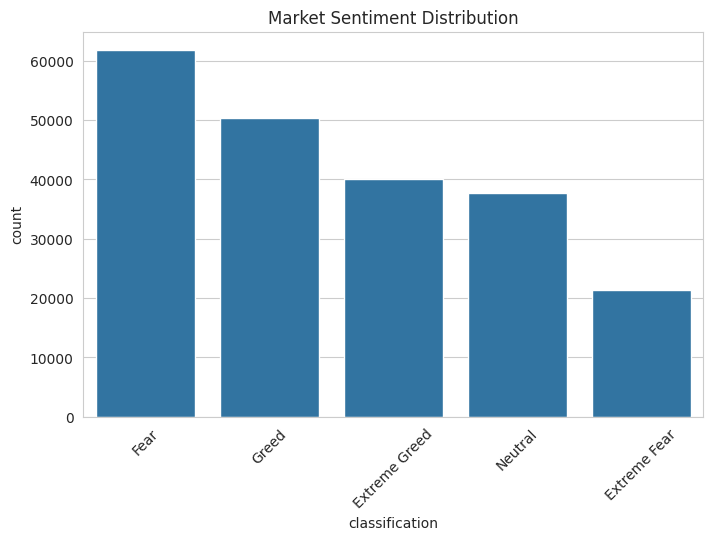

In [90]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="classification", order=df["classification"].value_counts().index)

plt.title("Market Sentiment Distribution")
plt.xticks(rotation=45)

plt.show()

###**2. Profitability Across Sentiment Regimes**

Profitability is measured using Closed PnL.

The objective is to determine whether traders perform differently during Fear and Greed periods.

In [91]:
pnl_analysis = (df.groupby("classification")["Closed PnL"].agg(["count", "mean", "median", "sum"]))

pnl_analysis

,count,mean,median,sum
classification,,,,
Extreme Fear,21400,34.537862,0.0,7.391102e+05
Extreme Greed,39992,67.892861,0.0,2.715171e+06
Fear,61837,54.290400,0.0,3.357155e+06
Greed,50303,42.743559,0.0,2.150129e+06
Neutral,37686,34.307718,0.0,1.292921e+06


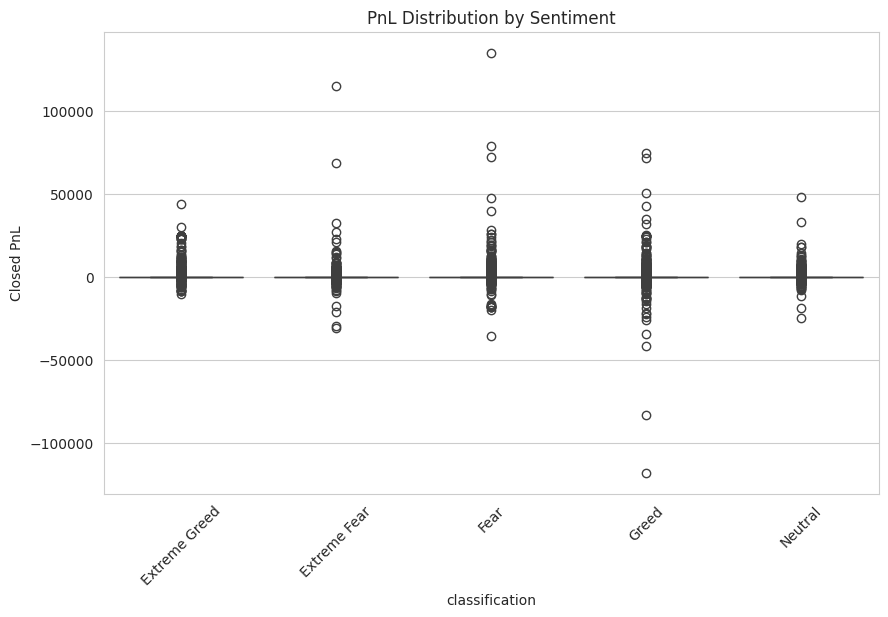

In [92]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="classification", y="Closed PnL")

plt.xticks(rotation=45)

plt.title("PnL Distribution by Sentiment")

plt.show()

### Observation

The boxplot highlights differences in trader profitability across sentiment conditions.

Higher average and median PnL values suggest stronger performance under specific market sentiment regimes.

###**3. Win Rate Analysis**

Win rate measures the proportion of profitable trades.

This metric helps evaluate whether sentiment affects trading success rates.

In [93]:
win_rate_analysis = (df.groupby("classification")["win"].mean()* 100)

win_rate_analysis

,win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


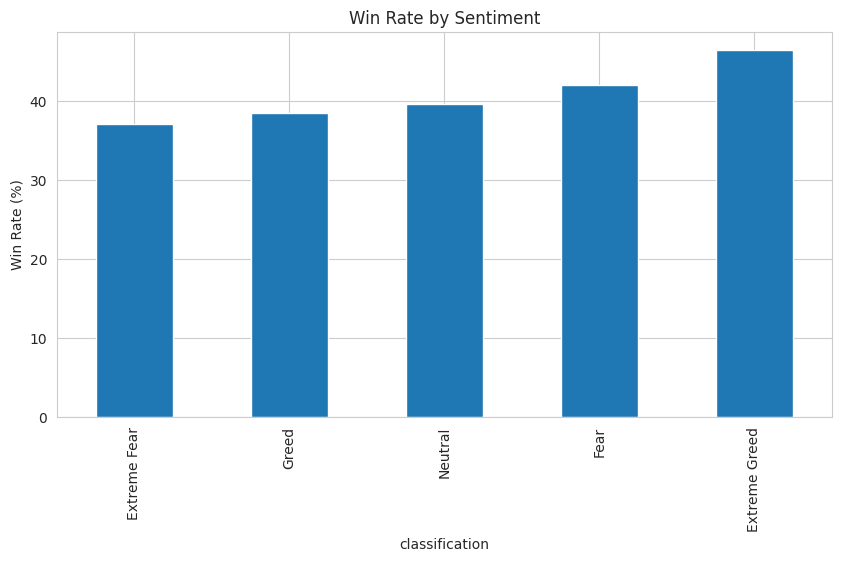

In [94]:
win_rate_analysis.sort_values().plot(kind="bar", figsize=(10,5))

plt.ylabel("Win Rate (%)")
plt.title("Win Rate by Sentiment")

plt.show()

###**4. Average Trade Size**

Average trade size measures how much capital traders deploy under different market conditions.

Larger position sizes may indicate greater confidence or risk-taking behavior.

In [95]:
trade_size_analysis = (df.groupby("classification")["Size USD"].mean())

trade_size_analysis

,Size USD
classification,
Extreme Fear,5349.731843
Extreme Greed,3112.251565
Fear,7816.109931
Greed,5736.884375
Neutral,4782.732661


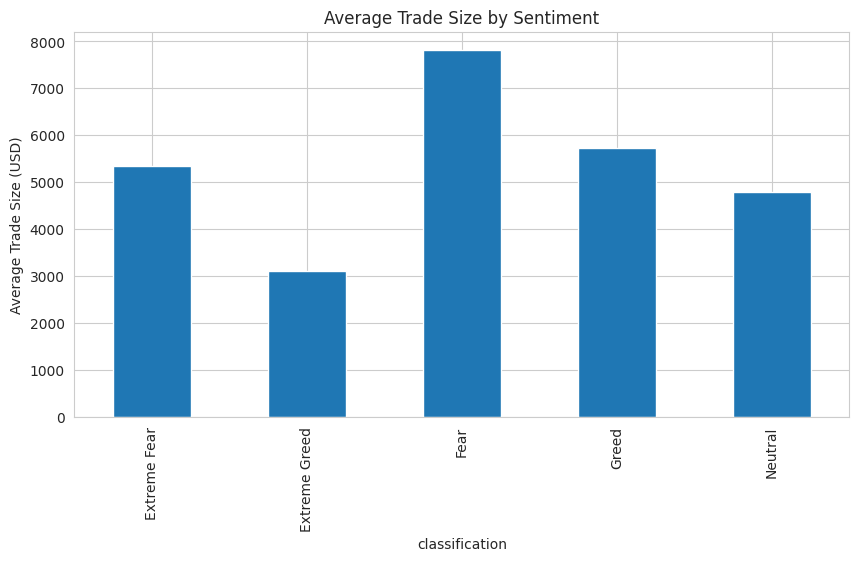

In [96]:
trade_size_analysis.plot(kind="bar", figsize=(10,5))

plt.ylabel("Average Trade Size (USD)")
plt.title("Average Trade Size by Sentiment")

plt.show()

###**5. Trading Activity**

Trading activity is measured using the total number of trades executed under each sentiment condition.

Higher activity levels may indicate stronger trader participation.

In [97]:
activity_analysis = (df.groupby("classification").size().reset_index(name="trade_count"))

activity_analysis

,classification,trade_count
0,Extreme Fear,21400
1,Extreme Greed,39992
2,Fear,61837
3,Greed,50303
4,Neutral,37686


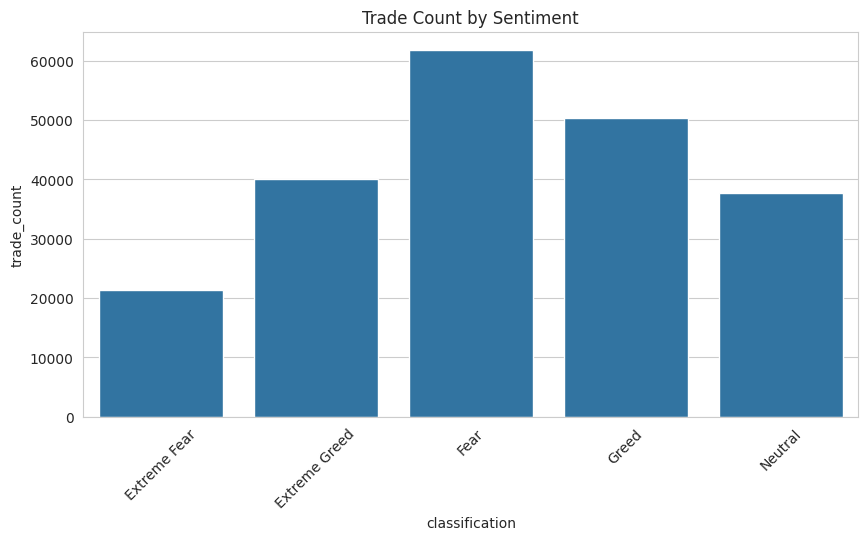

In [98]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=activity_analysis,
    x="classification",
    y="trade_count"
)

plt.xticks(rotation=45)

plt.title("Trade Count by Sentiment")

plt.show()

###**6. Long vs Short Bias**

This analysis investigates whether traders prefer long or short positions under different sentiment conditions.

In [99]:
direction_analysis = pd.crosstab(df["classification"], df["Direction"], normalize="index")

direction_analysis

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0.000000,0.037710,0.291636,0.145654,0.00000,0.000234,0.327336,0.148318,0.048692,0.00000,0.000280,0.000140
Extreme Greed,0.000000,0.128326,0.179686,0.162457,0.00000,0.000175,0.157532,0.191613,0.179136,0.00000,0.000275,0.000800
Fear,0.000000,0.051862,0.279121,0.149118,0.00000,0.000226,0.288242,0.176060,0.054401,0.00000,0.000291,0.000679
Greed,0.000159,0.093136,0.158996,0.225076,0.00002,0.000318,0.169851,0.231875,0.118999,0.00002,0.000457,0.001093
Neutral,0.000000,0.076554,0.265165,0.155230,0.00000,0.000398,0.271241,0.168577,0.062251,0.00000,0.000318,0.000265


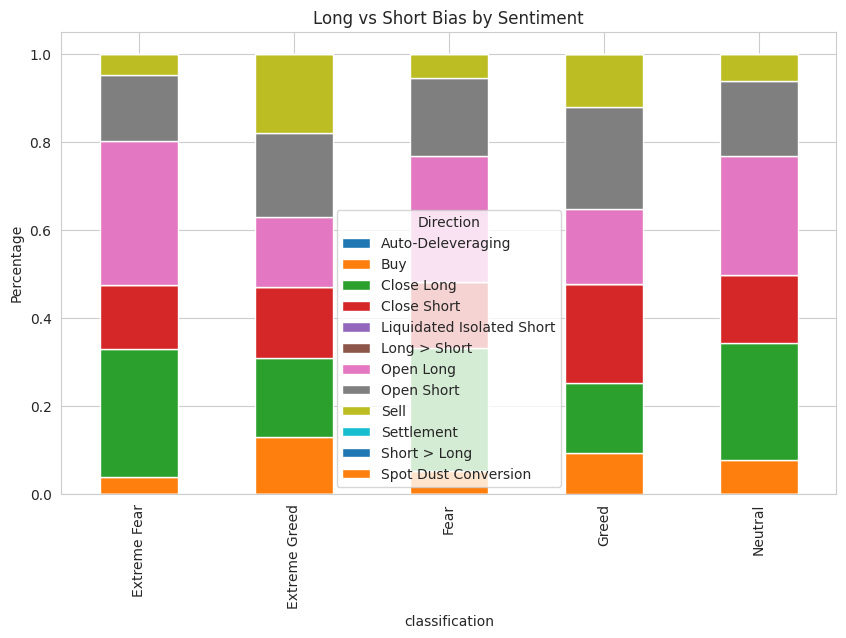

In [100]:
direction_analysis.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Long vs Short Bias by Sentiment")

plt.ylabel("Percentage")

plt.show()

---
## **Statistical Significance Test**

---

A Welch's t-test was performed to determine whether profitability differs significantly between Fear and Greed periods.

###*Interpretation:*

If p-value < 0.05:

The difference in profitability between Fear and Greed periods is statistically significant.

If p-value ≥ 0.05:

The observed difference may be due to random variation.

In [51]:
fear = df[df["classification"].str.contains("Fear",na=False)]["Closed PnL"]

greed = df[df["classification"].str.contains("Greed",na=False)]["Closed PnL"]

In [52]:
t_stat, p_value = ttest_ind(fear, greed, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: -0.9875081966653334
P-value: 0.32339495608436075


Since the p-value is greater than the 0.05 significance threshold, the difference in average profitability between Fear and Greed periods is not statistically significant.

This suggests that market sentiment alone may not be a strong predictor of trader profitability. Other factors such as trading frequency, position sizing, trader experience, and risk management practices may have a greater influence on trading outcomes.

---
#**Trader Segmentation**
---

To better understand trader behavior, traders were segmented based on their activity levels and trading performance.

The objective is to identify distinct trader groups and compare their profitability characteristics.

The following segments were created:

1. Frequent vs Infrequent Traders
2. Consistent Winners vs Inconsistent Traders
3. Behavioral Clusters using K-Means Clustering

Account Metrics

In [104]:
account_stats = (df.groupby("Account").agg({"Closed PnL":"mean", "win":"mean", "Size USD":"mean", "Trade ID":"count"}))

In [105]:
account_stats.columns = ["avg_pnl", "win_rate", "avg_trade_size", "trade_count"]

## **Frequent vs Infrequent**

Traders were divided into two groups based on the median number of trades executed.

- Frequent Traders: Above median trade count
- Infrequent Traders: Below median trade count

This segmentation helps determine whether higher trading activity is associated with improved profitability.

In [106]:
median_trade_count = (account_stats["trade_count"].median())

account_stats["frequency_segment"] = np.where(account_stats["trade_count"] > median_trade_count, "Frequent", "Infrequent")

In [107]:
frequency_results = (account_stats.groupby("frequency_segment")[["avg_pnl","win_rate","trade_count"]].mean())

frequency_results

,avg_pnl,win_rate,trade_count
frequency_segment,,,
Frequent,57.577434,0.413562,11684.8125
Infrequent,137.795158,0.392563,1516.6875


## **Consistent Winners**

Traders with win rates greater than 55% were classified as Consistent Winners.

All remaining traders were classified as Inconsistent Traders.

This analysis investigates whether consistently successful traders exhibit different trading behaviors.

In [109]:
account_stats["winner_segment"] = np.where(account_stats["win_rate"] > 0.55,"Consistent Winner", "Inconsistent")

In [110]:
winner_results = (account_stats.groupby("winner_segment")[["avg_pnl","win_rate","avg_trade_size"]].mean())

winner_results

,avg_pnl,win_rate,avg_trade_size
winner_segment,,,
Consistent Winner,106.505684,0.692009,2333.733629
Inconsistent,97.098337,0.383799,6252.875752



## **Clustering**



**K-Means** clustering was used to identify naturally occurring trader groups based on:

- Average Profitability
- Win Rate
- Average Trade Size
- Trading Frequency

This approach helps uncover trader archetypes without manually defining categories.

In [112]:
cluster_features = account_stats[["avg_pnl", "win_rate", "avg_trade_size", "trade_count"]]

In [113]:
scaler = StandardScaler()

X = scaler.fit_transform(cluster_features)

In [114]:
kmeans = KMeans(n_clusters=3, random_state=42)

account_stats["Cluster"] = kmeans.fit_predict(X)

In [115]:
account_stats.groupby("Cluster").mean(
    numeric_only=True
)

,avg_pnl,win_rate,avg_trade_size,trade_count
Cluster,,,,
0,206.036166,0.439780,10357.837334,4009.500000
1,38.390661,0.379881,1915.636756,20003.833333
2,30.227394,0.381526,4033.276520,3077.642857


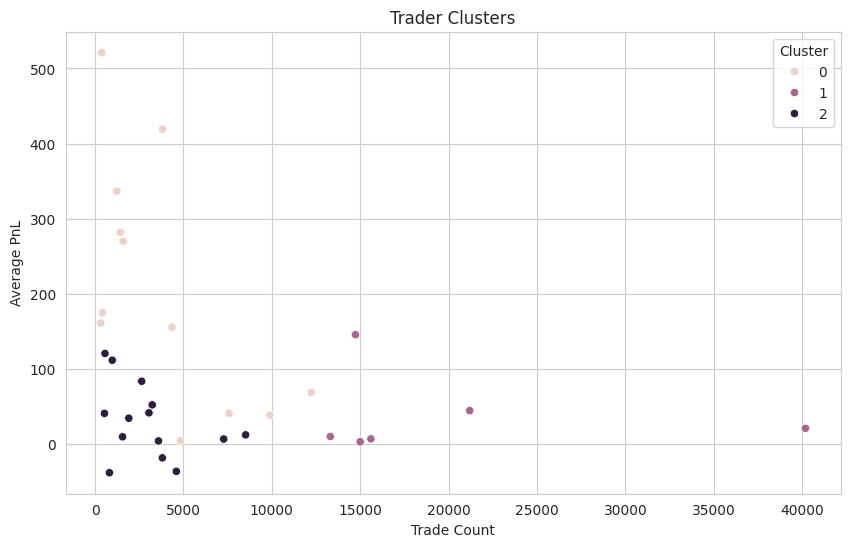

In [119]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=account_stats,
    x="trade_count",
    y="avg_pnl",
    hue="Cluster"
)

plt.title("Trader Clusters")

plt.xlabel("Trade Count")
plt.ylabel("Average PnL")

plt.savefig("cluster_plot.png", bbox_inches="tight")

plt.show()

---
#**Key Insights**
---

## 1: Extreme Greed Produced the Best Trading Outcomes

Extreme Greed periods generated the highest average trader profitability (67.89) and the highest win rate (46.49%).

This suggests traders generally benefited from strong directional market momentum during highly optimistic market conditions.



## 2: Traders Took Larger Risks During Fear

Despite lower profitability, traders deployed the largest average position sizes during Fear periods (approximately $7,816 per trade).

This indicates that traders increased capital exposure during uncertain market conditions, potentially increasing downside risk.



## 3: Fear Generated the Highest Trading Activity

Fear periods accounted for the highest number of trades (61,837 trades).

This suggests traders were more active during uncertain markets, likely attempting to capture volatility-driven opportunities.



## 4: Trading More Frequently Did Not Necessarily Improve Profitability

Frequent traders achieved a slightly higher win rate (41.36%) but lower average profitability (57.58).

In contrast, infrequent traders generated substantially higher average profitability (137.80) despite lower trade frequency.

This suggests that trade quality may be more important than trade quantity.



## 5: Consistent Winners Used Smaller Position Sizes

Consistent winners achieved a win rate of 69.2% while using significantly smaller average position sizes ($2,334).

Inconsistent traders deployed much larger average positions ($6,253) but achieved lower win rates (38.4%).

This suggests disciplined position sizing may contribute to long-term trading success.



## 6: Market Sentiment Alone Was Not Statistically Significant

Although profitability appeared higher during Greed conditions, the Welch's t-test produced a p-value of 0.323.

Therefore, the difference in profitability between Fear and Greed periods was not statistically significant at the 5% significance level.

This indicates that trader behavior and risk management may be more important than sentiment alone.

---
# **Strategy Recommendations**
---

Based on the analysis, the following trading guidelines are proposed.

## Strategy 1: Reduce Position Sizes During Fear Periods

Observation:

Traders used the largest average position sizes during Fear periods while achieving lower profitability compared to Extreme Greed periods.

Recommendation:

- Reduce leverage and position sizes during Fear conditions.
- Focus on capital preservation rather than aggressive risk-taking.
- Apply stricter stop-loss levels.

Expected Benefit:

Lower drawdowns during volatile market conditions.
## Strategy 2: Prioritize High-Conviction Trades Over High Frequency

Observation:

Infrequent traders generated substantially higher average profitability than frequent traders.

Recommendation:

- Avoid overtrading.
- Enter positions only when strong setups are present.
- Use sentiment as a confirmation signal rather than a primary trading trigger.

Expected Benefit:

Improved risk-adjusted returns and reduced transaction costs.
## Strategy 3: Adopt Position Sizing Patterns of Consistent Winners

Observation:

Consistent winners maintained much smaller average position sizes while achieving significantly higher win rates.

Recommendation:

- Limit position size as a percentage of account capital.
- Scale positions gradually instead of taking large exposures.
- Emphasize consistency over short-term gains.

Expected Benefit:

More stable profitability and improved long-term survival.